In [1]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

[[2.91308879e-06]
 [2.91308879e-06]]
[[0.00291307]
 [0.00291307]]
[[[ 10.00005503   0.        ]]

 [[  0.           0.        ]]

 [[-10.00005503   0.        ]]]


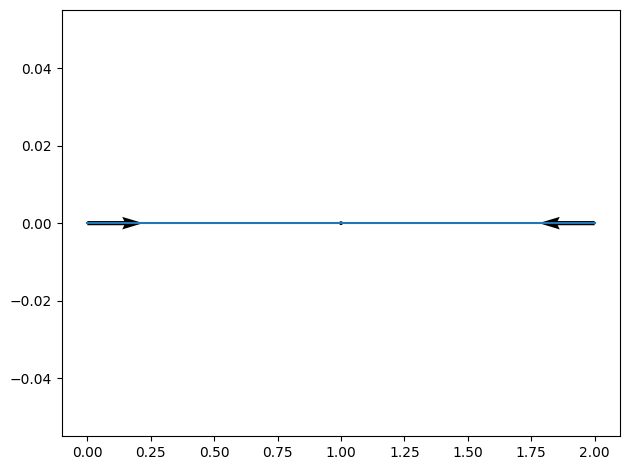

In [8]:
from ael.score_function import compute_velocity_score_batched_helper
import numpy as np
import matplotlib.pyplot as plt

SIGMA = 0.01
# MAX_SPEED = 1.00000000001
MAX_SPEED = 0.999

xy_T_B_D = np.array([[[0.0, 0.0]], [[1.0, 0.0]], [[2.0, 0.0]]])
max_speed_B = np.array([MAX_SPEED])
sigma_B = np.array([SIGMA])
score_T_B_D = compute_velocity_score_batched_helper(
    xy_T_B_D, max_speed_B, sigma_B, n_integral=10
)
# rescale to maximum norm of 100
score_T_B_D = score_T_B_D / (
    np.maximum(1, np.linalg.norm(score_T_B_D, axis=-1, keepdims=True) / 100)
)

print(score_T_B_D)

plt.plot(xy_T_B_D[:, 0, 0], xy_T_B_D[:, 0, 1])
plt.quiver(
    xy_T_B_D[:, 0, 0],
    xy_T_B_D[:, 0, 1],
    score_T_B_D[:, 0, 0],
    score_T_B_D[:, 0, 1],
    scale=100,
)
plt.tight_layout()
plt.show()
